In [1]:
import pickle
import numpy as np
from pathlib import Path
from tqdm import tqdm
from vebir.pca import loo_pca, malinowski_ind, pca
from vebir.ebs import EBS
from vebir.veb import VEB, norm_cdf, norm_pdf
from vebir.metrics_utils import compute_compound_cors, compute_method_cors
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import cvxpy as cp

In [203]:
REPO_ROOT = Path.cwd().resolve().parent
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"

GT_DIR = REPO_ROOT / "data" / "spectrabase" / "teflon"
LAB_DIR = REPO_ROOT / "data" / "raw" / "teflon" / "laboratory_samples"
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"

with open(PREPROC_DIR / "blanks_dict.pkl", "rb") as f:
    blanks_dict = pickle.load(f)

with open(GT_DIR / "ref_dict.pkl", "rb") as file:
    ref_dict = pickle.load(file)

CO2 = ref_dict["CO2"]
H2O = np.array(pd.read_csv("../data/spectrabase/teflon/H2O_spectrum.csv"))

del ref_dict["CO2"]

wn = np.sort(pd.read_csv(LAB_DIR / "zerofilling.txt", header=None).iloc[:, 0])

In [204]:
with open(PREPROC_DIR  / 'blanks_dict.pkl', 'rb') as f:
    blanks_dict = pickle.load(f)

with open(PREPROC_DIR  / "raw_spectra_dict.pkl", 'rb') as file:
    raw_spectra_dict = pickle.load(file) 
    
Z = blanks_dict["2011"]
wn = Z.columns
Z = np.array(Z)
Y = np.array(raw_spectra_dict["Ammonium sulfate"]["raw"])

In [207]:
def veb_pb_elbo(y, tau, nu, d, f, mu, W, V):
    p, c = y.shape[0], W.shape[1]

    theta = y - mu - W @ nu - V @ f
    delta = np.sqrt(np.sum((W * d) ** 2, axis=1))
    z = theta / delta

    g = theta * norm_cdf(z) + delta * norm_pdf(z) + (tau - 1) * theta
    sigma_hat = np.mean(g)

    return (
        p * np.log(tau)
        + p * np.log(1 - tau)
        - p * np.log(sigma_hat)
        - 0.5 * np.sum(nu**2)
        - 0.5 * np.sum(d**2)
        + np.sum(np.log(d))
        + (c / 2 - p)
    )


In [216]:
Z = blanks_dict["2011"]
wn = Z.columns
Z = np.array(Z)

_ , chat_ose, _ = loo_pca(Z, detrend=True)
mu, _, _, W = pca(Z,detrend=True)
W = W[:,:chat_ose]

V = np.hstack([CO2[:,[1]], H2O[:,[1]]])

In [222]:
y = Y[5,:]
tau = 0.1
nu = np.random.normal(size=W.shape[1]) 
d = np.ones(W.shape[1])
f = np.random.normal(size=V.shape[1]) 

In [223]:
veb_pb_elbo(y, tau, nu, d, f, mu, W, V)

np.float64(2844.67389544865)

In [230]:
def veb_pb_jac_elbo(y, tau, nu, d, f, mu, W, V):
    p = y.shape[0]

    theta = y - mu - W @ nu - V @ f
    delta = np.sqrt(np.sum((W * d) ** 2, axis=1))
    z = theta / delta

    Phi = norm_cdf(z)
    phi = norm_pdf(z)
    g = theta * Phi + delta * phi + (tau - 1) * theta
    sigma_hat = np.mean(g)

    dtau = p / tau - p / (1 - tau) - np.sum(theta) / sigma_hat
    dnu = -(W.T @ ((1 - tau) - Phi)) / sigma_hat - nu
    dd = 1 / d - d - ((W**2).T @ (phi / delta)) * (d / sigma_hat)
    df = -(V.T @ ((1 - tau) - Phi)) / sigma_hat 
    
    return dtau, dnu, dd, df

In [231]:
h = 1e-8
(veb_pb_elbo(y, tau+h, nu, d, f, mu, W, V) - veb_pb_elbo(y, tau-h, nu, d, f, mu, W, V)) / (2 * h), veb_pb_jac_elbo(y, tau, nu, d, f, mu, W, V)[0]

(np.float64(-1638.925004954217), np.float64(-1638.9251376268112))

In [232]:
h = 1e-8
for i in range(W.shape[1]):
    nuh = nu.copy()
    nuh[i] += h
    print((veb_pb_elbo(y, tau, nuh, d, f, mu, W, V) - veb_pb_elbo(y, tau, nu, d, f, mu, W, V)) / h, veb_pb_jac_elbo(y, tau, nu, d, f, mu, W, V)[1][i])

886.9438715919387 886.9439003778539
-19.860999600496143 -19.860934148532
6.265963747864589 6.265961127957582
-2.8648173611145467 -2.8648620086603205
-8.793631423031911 -8.793602662163282
-5.555921234190464 -5.556044970057919
13.960561773274094 13.960517688751505
1.0449184628669173 1.0450080963346213
-1.0639269021339715 -1.0639348692929433
-0.5205947672948241 -0.5206091736644362
-2.375054464209825 -2.375035666712647
-2.082470018649474 -2.0824222541260493
-1.6774720279499888 -1.6776068414947245
-1.5140358300413936 -1.5138961207291857
-1.3126737030688673 -1.3126547081573692
1.1680640454869717 1.168087115553195
0.9615177987143397 0.9615512490392175
-2.7361238608136773 -2.736076965319379
0.6164555088616908 0.6162119298637426
-1.5024852473288774 -1.5023599027259853
0.02964952727779746 0.02958179793908052
-0.41909515857696533 -0.4191952433652828
-1.5975274436641484 -1.597631502060878
0.09649738785810769 0.09644866991458056
-0.39208316593430936 -0.3920842530880365
1.1129486665595323 1.11281757

In [233]:
h = 1e-6
for i in range(W.shape[1]):
    dh = d.copy()
    dh[i] += h
    print((veb_pb_elbo(y, tau, nu, dh, f, mu, W, V) - veb_pb_elbo(y, tau, nu, d, f, mu, W, V)) / h, veb_pb_jac_elbo(y, tau, nu, d, f, mu, W, V)[2][i])

-216.64159885403933 -216.64109497790704
-3.837551957985852 -3.837548817149828
-3.3641163099673577 -3.364113597424869
-0.5107949618832208 -0.5107940921814353
-1.4847310012555681 -1.4847285702792408
-0.49728168960427865 -0.49727908082682826
-1.2924874681630172 -1.2924838562680083
-0.03504192136460915 -0.035040558681840486
-0.031725903681945056 -0.03172440349784913
-0.011347765394020826 -0.01134626787281176
-0.003940840542782098 -0.003940065310414627
-0.006360096449498087 -0.0063600302198729315
-0.006598384061362594 -0.0065960115486279535
-0.0021600499167107046 -0.002158402144345399
-0.000924956111703068 -0.0009252028682317571
-0.0008958522812463343 -0.0008942064529216296
-0.0005047695594839752 -0.0005053505572180128
-0.0005029505700804293 -0.0005017388511623988
-0.0008794813766144216 -0.000877904946115461
-0.0006775735528208315 -0.0006778736858696385
-0.00028830982046201825 -0.0002867966077195925
-0.0006775735528208315 -0.0006777758158798686
-7.185008144006133e-05 -7.181827906805117e-05


In [235]:
h = 1e-8
for i in range(V.shape[1]):
    fh = f.copy()
    fh[i] += h
    print((veb_pb_elbo(y, tau, nu, d, fh, mu, W, V) - veb_pb_elbo(y, tau, nu, d, f, mu, W, V)) / h, veb_pb_jac_elbo(y, tau, nu, d, fh, mu, W, V)[3][i])

281.3510945998132 281.35120885968337
-4.498360794968903 -4.498401454115123


In [293]:
def veb_pb_optim_prep(
    y, tau_init, nu_init, d_init, f_init, mu, W, V, tau_min=1e-5, tau_max=0.25, sd_min=1e-10
):
    c = nu_init.shape[0]
    nu_slice = slice(1, 1 + c)
    d_slice = slice(1 + c, 1 + 2*c)
    f_slice = slice(1 + 2*c, None)

    def fun(pars):
        return -veb_pb_elbo(y, pars[0], pars[nu_slice], pars[d_slice], pars[f_slice], mu, W, V)

    def jac_fun(pars):
        dtau, dnu, dd, df = veb_pb_jac_elbo(
            y, pars[0], pars[nu_slice], pars[d_slice], pars[f_slice], mu, W, V
        )
        return -np.concatenate(([dtau], dnu, dd, df))

    init = np.concatenate(([tau_init], nu_init, d_init, f_init))
    bnds = ((tau_min, tau_max),) + ((-np.inf, np.inf),) * c + ((sd_min, np.inf),) * c + ((-np.inf, np.inf),) * V.shape[1]

    return fun, jac_fun, init, bnds

def pb_sigma_hat(y, tau, nu, d, f, mu, W, V):
    theta = y - mu - W @ nu - V @ f
    delta = np.sqrt(np.sum((W * d) ** 2, axis=1))
    z = theta / delta

    Phi = norm_cdf(z)
    phi = norm_pdf(z)
    g = theta * Phi + delta * phi + (tau - 1) * theta
    sigma_hat = np.mean(g)

    return sigma_hat

def pb_map(y, mu, W, V, tau, sigma, mit=None, verbose=False):
    x = cp.Variable(W.shape[1])
    f = cp.Variable(V.shape[1])
    prob = cp.Problem(
        cp.Minimize(
            cp.sum(0.5 * cp.abs(y - mu - W @ x - V @ f) + (tau - 0.5) * (y - mu - W @ x - V @ f ))
            + 0.5 * sigma * cp.sum_squares(x)
        )
    )

    prob.solve(solver=cp.CLARABEL, verbose=verbose)

    return mu + W @ x.value, V@f.value ,x.value , f.value

In [261]:
Y = np.array(raw_spectra_dict["Malonic Acid"]["raw"])

In [262]:
_ , chat_ose, _ = loo_pca(Z, detrend=True)
mu, _, _, W = pca(Z,detrend=True)
W = W[:,:chat_ose]
V = np.hstack([CO2[:,[1]], H2O[:,[1]]])

In [306]:
y = Y[3,:]
tau = 0.1
nu = np.zeros(W.shape[1])
d = np.ones(W.shape[1])
f = np.zeros(V.shape[1])

In [307]:
fun, jac_fun, init, bnds = veb_pb_optim_prep(
    y, tau, nu, d, f, mu, W, V, tau_min=1e-5, tau_max=0.25, sd_min=1e-10
)

In [308]:
opt = minimize(
                fun,
                init,
                method="L-BFGS-B",
                jac=jac_fun,
                bounds=bnds,
                options={"maxiter": 20000},
            )

In [309]:
tau, nu, t0 = opt.x[0], opt.x[1 : (1 + W.shape[1])], W.shape[1] + 1
d = opt.x[t0:(t0 + W.shape[1])]
t0 += W.shape[1]
f = opt.x[t0:]
sigma_hat = pb_sigma_hat(y, tau, nu, d, f, mu, W, V)

In [310]:
z, v, _,_ = pb_map(y, mu, W, V, tau, sigma_hat, mit=None, verbose=False)

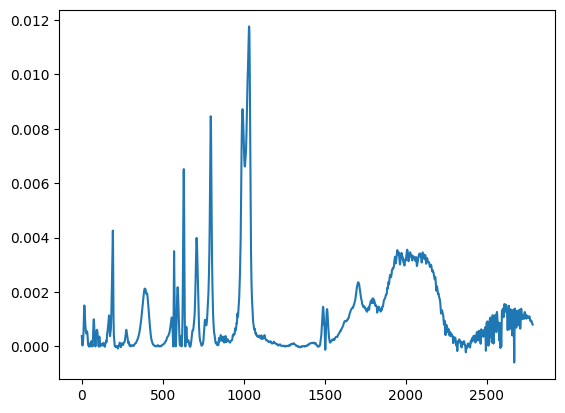

In [311]:
plt.plot(y-z-v)

In [351]:
comp = "fructose"

_ , chat_ose, _ = loo_pca(Z, detrend=True)
mu, _, _, W = pca(Z,detrend=True)
W = W[:,:chat_ose]

V = np.hstack([CO2[:,[1]]])

In [352]:
corrections = []

In [353]:
Y = np.array(raw_spectra_dict[comp]["raw"])
for i in tqdm(range(Y.shape[0])):
    y = Y[i,:]
    nu = np.zeros(W.shape[1])
    f = np.zeros(V.shape[1])
    d = np.ones(W.shape[1])
    tau = 0.1
    
    fun, jac_fun, init, bnds = veb_pb_optim_prep(
        y, tau, nu, d, f, mu, W, V, tau_min=1e-5, tau_max=0.25, sd_min=1e-10
    )    
    
    opt = minimize(
                fun,
                init,
                method="L-BFGS-B",
                jac=jac_fun,
                bounds=bnds,
                options={"maxiter": 10000},
            )
    
    tau, nu, t0 = opt.x[0], opt.x[1 : (1 + W.shape[1])], W.shape[1] + 1
    d = opt.x[t0:(t0 + W.shape[1])] 
    t0 += W.shape[1]
    f = opt.x[t0:]
    sigma_hat = pb_sigma_hat(y, tau, nu, d, f, mu, W, V)
    
    z, z1, _,_ = pb_map(y, mu, W, V, tau, sigma_hat, mit=None, verbose=False)
    
    corrections.append(y - z - z1)

100%|██████████| 17/17 [05:35<00:00, 19.75s/it]


In [354]:
corrections = np.array(corrections)
ref_profile = ref_dict[comp][:, 1]
ref_wn = ref_dict[comp][:, 0]
interpolated_corrections = [np.interp(ref_wn, wn, c) for c in corrections]
corrs = np.array(
            [np.corrcoef(ref_profile, c)[0, 1] for c in interpolated_corrections]
        )
print(corrs)
print(np.mean(corrs))

[0.89229918 0.92110388 0.91912127 0.90183389 0.90532206 0.90113265
 0.89077089 0.85699438 0.86954723 0.85101602 0.84323329 0.79012139
 0.79443563 0.78692351 0.78250592 0.76951203 0.7448301 ]
0.8482766648054404


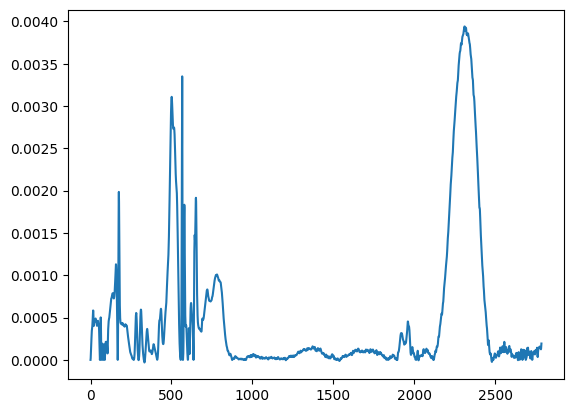

In [356]:
plt.plot(corrections[0])

In [187]:
corrections = np.array(corrections)
ref_profile = ref_dict[comp][:, 1]
ref_wn = ref_dict[comp][:, 0]
interpolated_corrections = [np.interp(ref_wn, wn, c) for c in corrections]
corrs = np.array(
            [np.corrcoef(ref_profile, c)[0, 1] for c in interpolated_corrections]
        )
print(corrs)
print(np.mean(corrs))

[0.73940675 0.68960858 0.6767941  0.68523208 0.71181009 0.68922839
 0.75275743 0.7387277  0.63451656 0.66163267 0.65101381 0.67905562
 0.71820882]
0.694460969445722


In [188]:
corrections

array([[ 1.37141622e-03,  1.18164317e-03,  7.54518235e-04, ...,
         4.60358672e-05,  3.24910208e-05, -1.64090204e-05],
       [ 6.16106947e-05,  5.46269363e-05,  2.44533647e-05, ...,
        -3.91421464e-04, -3.69097700e-04, -3.30816740e-04],
       [-1.52633125e-04, -9.57807454e-05, -6.77967404e-12, ...,
        -4.52731388e-04, -5.83539702e-04, -7.16291655e-04],
       ...,
       [-4.90607214e-05,  2.79594276e-05,  6.49107061e-05, ...,
        -4.00837650e-04, -4.48611679e-04, -4.77728884e-04],
       [-5.42513700e-05,  1.42963419e-12,  6.48939791e-05, ...,
        -5.96816651e-04, -5.84365602e-04, -5.64611824e-04],
       [ 2.38594795e-04,  1.48254312e-04,  6.48706836e-05, ...,
        -7.66493194e-04, -6.68824674e-04, -5.59718730e-04]],
      shape=(13, 2785))

In [590]:
def veb_pb_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2):
    p, c1 = y.shape[0], W1.shape[1] 
    theta = y - mu - W1 @ nu1- W2 @ nu2
    delta = np.sqrt(np.sum((W1 * d1) ** 2, axis=1) + np.sum((W2 * d2) ** 2, axis=1))
    z = theta / delta
    g = theta * norm_cdf(z) + delta * norm_pdf(z) + (tau - 1) * theta
    sigma_hat = np.mean(g)
    gamma = np.sqrt(d2**2 + nu2**2)
    
    return (c1/2 - p) + p * np.log(tau) + p * np.log(1 - tau) - p * np.log(sigma_hat) - 0.5 * np.sum(nu1**2) - 0.5 * np.sum(d1**2) + np.sum(np.log(d1) + np.log(d2)) - 0.5*np.sum(np.log(gamma*2))


In [591]:
Z = blanks_dict["2011"]
wn = Z.columns
Z = np.array(Z)

In [592]:
_ , chat_ose, _ = loo_pca(Z, detrend=True)
mu, _, _, W1 = pca(Z,detrend=True)
W1 = W1[:,:chat_ose]
W2 = CO2[:,[1]]

In [593]:
tau = 0.1 
nu1 = np.zeros(W1.shape[1]) + 1
nu2 = np.zeros(W2.shape[1]) + 1
d1 = np.ones(W1.shape[1]) + 1
d2 = np.ones(W2.shape[1]) + 1

comp = "Malonic Acid"
Y = np.array(raw_spectra_dict[comp]["raw"])
y = Y[3,:]

In [594]:
d2

array([2.])

In [595]:
veb_pb_elbo(y, tau, nu1, nu2, d2, d2, mu, W1, W2)

np.float64(-2305.1521222773285)

In [596]:
def veb_pb_jac_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2):
    p = y.shape[0]

    theta = y - mu - W1 @ nu1 - W2 @ nu2
    delta = np.sqrt(np.sum((W1 * d1) ** 2, axis=1) + np.sum((W2 * d2) ** 2, axis=1))
    z = theta / delta

    Phi = norm_cdf(z)
    phi = norm_pdf(z)
    g = theta * Phi + delta * phi + (tau - 1) * theta
    sigma_hat = np.mean(g)
    gamma = np.sqrt(d2**2 + nu2**2)

    dtau = p / tau - p / (1 - tau) - np.sum(theta) / sigma_hat
    dnu1 = -(W1.T @ ((1 - tau) - Phi)) / sigma_hat - nu1 
    dd1 = 1 / d1 - d1 - ((W1**2).T @ (phi / delta)) * (d1 / sigma_hat) 
    dnu2 = -(W2.T @ ((1 - tau) - Phi)) / sigma_hat - nu2 / gamma / gamma
    dd2 = 1 / d2 - d2 /gamma /gamma - ((W2**2).T @ (phi / delta)) * (d2 / sigma_hat) 


    return dtau, dnu1, dnu2, dd1, dd2

In [597]:
h = 1e-8
print((veb_pb_elbo(y, tau + h, nu1, nu2, d1, d2, mu, W1, W2) - veb_pb_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2))/h,veb_pb_jac_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2)[0])

27157.176828040974 27157.177912697185


In [598]:
h = 1e-8
for i in range(W1.shape[1]):
    nu1_h = nu1.copy()
    nu1_h[i] += h
    print((veb_pb_elbo(y, tau, nu1_h, nu2, d1, d2, mu, W1, W2) - veb_pb_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2))/h,veb_pb_jac_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2)[1][i])

-953.3256161375903 -953.3257023783003
2.054275682894513 2.054192808458076
-25.87066774140112 -25.870763181359987
2.992510417243466 2.9924062819667623
-3.736113285413012 -3.7362988294889887
-3.930927050532773 -3.9310313876573795
3.546301741153002 3.5462620615729845
-0.8618371794000268 -0.8618755461832956
-1.0453732102178037 -1.0454413889059326
-1.1820702638942748 -1.1820639191291056
-0.9553332347422838 -0.9554146991397754
-1.0495568858459592 -1.0496927525595776
-0.9611540008336306 -0.9611522753805675
-0.9875293471850455 -0.987602302384832
-0.9815266821533442 -0.9816259512849651
-1.0199073585681617 -1.0199802267478553
-1.0055373422801495 -1.005594267928278
-1.005082594929263 -1.0051605239543908
-0.9878931450657547 -0.9879593963226189
-0.9979885362554342 -0.9981004751982115
-1.000444171950221 -1.0004570812532523
-1.01190380519256 -1.0120299535056259
-0.9999894245993346 -1.000091658488259
-0.9958057489711791 -0.9958159087923955
-1.0014446161221713 -1.0015773234246512
-0.9958057489711791 -0

In [599]:
h = 1e-8
for i in range(W2.shape[1]):
    nu2_h = nu2.copy()
    nu2_h[i] += h
    print((veb_pb_elbo(y, tau, nu1, nu2_h, d1, d2, mu, W1, W2) - veb_pb_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2))/h,veb_pb_jac_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2)[2][i])

-272.0460088312393 -272.1460785370635


In [600]:
h = 1e-8
for i in range(W1.shape[1]):
    d1_h = d1.copy()
    d1_h[i] += h
    print((veb_pb_elbo(y, tau, nu1, nu2, d1_h, d2, mu, W1, W2) - veb_pb_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2))/h,veb_pb_jac_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2)[3][i])

-471.34130909398664 -471.34137667895266
-3.42911334882956 -3.4292658628952086
-3.5026005207328126 -3.5026741497758374
-1.7311776900896803 -1.7313011513378913
-1.7634647520026192 -1.763447107722295
-1.6198555385926738 -1.6199216909835397
-1.8414993974147364 -1.8415102745432064
-1.5101704775588587 -1.510134104194775
-1.5103523764992133 -1.5103851158094046
-1.5086243365658447 -1.5086894245847755
-1.503440216765739 -1.5035351134283836
-1.5035311662359163 -1.5036995718276065
-1.5017121768323705 -1.5017876633892175
-1.5008936316007748 -1.5009544374086305
-1.5004388842498884 -1.5004608572568248
-1.5002569853095338 -1.5003825908018757
-1.5000750863691792 -1.5002240996026317
-1.5000750863691792 -1.5002111985604183
-1.5000750863691792 -1.5002402357174183
-1.5000750863691792 -1.500160924560581
-1.499984136899002 -1.5000801414860503
-1.5000750863691792 -1.5001524835032392
-1.499984136899002 -1.5000358639518765
-1.499984136899002 -1.5000278042457396
-1.499984136899002 -1.5000516317670878
-1.4999841

In [601]:
h = 1e-10
for i in range(W2.shape[1]):
    d2_h = d2.copy()
    d2_h[i] += h
    print((veb_pb_elbo(y, tau, nu1, nu2, d1, d2_h, mu, W1, W2) - veb_pb_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2))/h,veb_pb_jac_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2)[4][i])

-123.51847544778138 -146.72328132961883


In [524]:
d2_h

array([2.])

In [76]:
def veb_pb_jac_elbo(y, tau, nu, d, mu, W):
    p = y.shape[0]

    theta = y - mu - W @ nu
    delta = np.sqrt(np.sum((W * d) ** 2, axis=1))
    z = theta / delta

    Phi = norm_cdf(z)
    phi = norm_pdf(z)
    g = theta * Phi + delta * phi + (tau - 1) * theta
    sigma_hat = np.mean(g)
    gamma = d**2 + nu**2

    dtau = p / tau - p / (1 - tau) - np.sum(theta) / sigma_hat
    dnu = -(W.T @ ((1 - tau) - Phi)) / sigma_hat - nu / gamma
    dd = 1 / d - d/gamma - ((W**2).T @ (phi / delta)) * (d / sigma_hat)

    return dtau, dnu, dd

def pb_sigma_hat(y, tau, nu, d, mu, W):
    theta = y - mu - W @ nu
    delta = np.sqrt(np.sum((W * d) ** 2, axis=1))
    z = theta / delta

    Phi = norm_cdf(z)
    phi = norm_pdf(z)
    g = theta * Phi + delta * phi + (tau - 1) * theta
    sigma_hat = np.mean(g)

    return sigma_hat


In [ ]:
_ , chat_ose, _ = loo_pca(Z, detrend=True)
mu, _, _, W = pca(Z,detrend=True)
W = W[:,:chat_ose]
y = Y[5,:]
nu = np.zeros(W.shape[1])
d = np.ones(W.shape[1])
tau = 0.1

In [55]:
veb_pb_elbo(y, tau, nu, d, mu, W)

np.float64(3832.36584218815)

In [56]:
h = 1e-8

print((veb_pb_elbo(y, tau+h, nu, d, mu, W) - veb_pb_elbo(y, tau, nu, d, mu, W) )/ h,veb_pb_jac_elbo(y, tau, nu, d, mu, W)[0])

6396.985190804116 6396.986148466738


In [57]:
h = 1e-8
for i in range(W.shape[1]):
    nu_h = nu.copy()
    nu_h[i] += h
    print((veb_pb_elbo(y, tau, nu_h, d, mu, W) - veb_pb_elbo(y, tau, nu, d, mu, W) )/h,veb_pb_jac_elbo(y, tau, nu_h, d, mu, W)[1][i])

-20.001789380330592 -20.001640476005235
-88.36705092107877 -88.36682303867866
-16.896774468477815 -16.89656342757283
-0.4687535692937672 -0.46863109670275943
-15.005389286670834 -15.005414925164624
-17.41427695378661 -17.41402371096388
31.861418392509222 31.86152972066929
5.680340109393001 5.680524709927776
0.914405973162502 0.9147091157400989
0.6784830475226045 0.6784706180948458
-1.297667040489614 -1.297633657888455
0.1355147105641663 0.1356614450496796
1.1728843674063683 1.173050710713222
0.38089638110250235 0.3811351460723971
-0.2772139851003885 -0.27722357891341043
0.13587850844487548 0.13594854398641693
0.008913048077374697 0.008966823482894258
-0.046202330850064754 -0.04601514443263185
0.1609805622138083 0.16121331488929627
-0.0012732925824820995 -0.0011775449837302305
-0.014551915228366852 -0.01437282937799082
-0.2104570739902556 -0.21038593555451324
-0.07130438461899757 -0.07118822038726025
0.06093614501878619 0.061086275625181506
0.16443664208054543 0.16469775394192518
0.0138

In [ ]:
h = 1e-5
d_h = d.copy()
d_h[0] += h

In [60]:

for i in range(W.shape[1]):
    d_h = d.copy()
    d_h[i] += h
    print((veb_pb_elbo(y, tau, nu, d_h, mu, W) - veb_pb_elbo(y, tau, nu, d, mu, W) )/h,veb_pb_jac_elbo(y, tau, nu, d, mu, W)[2][i])

-2161.1622785712825 -2161.153517123962
-18.461615945852827 -18.461526412211924
-11.040899698855354 -11.04084415239985
-2.6821167921298184 -2.682103417293447
-3.549723624018952 -3.5497060879359084
-1.3208426025812514 -1.3208360011661757
-1.6042155039031056 -1.6042072632221884
-0.04383146006148308 -0.04383111884261082
-0.06712798494845629 -0.06712741371681145
-0.034673576010391116 -0.03467339462366229
-0.018992795958183706 -0.01899279736626388
-0.01678472472121939 -0.01678439011976935
-0.00804921000963077 -0.008049181972277553
-0.00610161805525422 -0.006101538885515224
-0.0023734173737466335 -0.0023734066408147713
-0.002423621481284499 -0.0024235934479711384
-0.0016552803572267292 -0.0016550597934738911
-0.0011423253454267979 -0.0011421437706428522
-0.0018764694686979053 -0.0018762437171024819
-0.001156331563834101 -0.0011561842429712718
-0.000641375663690269 -0.0006412081008075329
-0.0007403286872431635 -0.0007401679079779825
-0.0003428795025683939 -0.00034280368074959214
-0.00022355379

In [61]:
def veb_pb_optim_prep(
    y, tau_init, nu_init, d_init, mu, W, tau_min=1e-5, tau_max=0.25, sd_min=1e-10
):
    c = nu_init.shape[0]
    nu_slice = slice(1, 1 + c)
    d_slice = slice(1 + c, None)

    def fun(pars):
        return -veb_pb_elbo(y, pars[0], pars[nu_slice], pars[d_slice], mu, W)

    def jac_fun(pars):
        dtau, dnu, dd = veb_pb_jac_elbo(
            y, pars[0], pars[nu_slice], pars[d_slice], mu, W
        )
        return -np.concatenate(([dtau], dnu, dd))

    init = np.concatenate(([tau_init], nu_init, d_init))
    bnds = ((tau_min, tau_max),) + ((-np.inf, np.inf),) * c + ((sd_min, np.inf),) * c

    return fun, jac_fun, init, bnds

In [218]:
all_cors = []
Z = blanks_dict["2011"]
wn = Z.columns
Z = np.array(Z)

In [247]:
_ , chat_ose, _ = loo_pca(Z, detrend=True)
mu, _, _, W = pca(Z,detrend=True)
W = W[:,:chat_ose]
W = np.hstack([W,CO2[:,[1]]])
chat_ose += 1

In [ ]:
comp = "Malonic Acid"
Y = np.array(raw_spectra_dict[comp]["raw"])
y = Y[3,:]

In [256]:
corrections = []
Y = np.array(raw_spectra_dict[comp]["raw"])
for i in tqdm(range(Y.shape[0])):
    y = Y[i,:]
    nu = np.zeros(W.shape[1])
    d = np.ones(W.shape[1])
    tau = 0.1
    
    fun, jac_fun, init, bnds = veb_pb_optim_prep(
                y, tau, nu, d, mu, W
            )

    opt = minimize(
                fun,
                init,
                method="L-BFGS-B",
                jac=jac_fun,
                bounds=bnds,
                options={"maxiter": 20000},
            )

    tau, nu, t0 = opt.x[0], opt.x[1 : (1 + chat_ose)], chat_ose + 1
    d = opt.x[t0:]
    sigma_hat = pb_sigma_hat(y, tau, nu, d, mu, W)
    gamma = d**2 + nu**2
    
    z,_ = pb_map(y, mu, W, tau, sigma_hat, gamma, mit=None, verbose=False)
    
    corrections.append(y - z)

100%|██████████| 13/13 [03:48<00:00, 17.55s/it]


In [257]:
corrections = np.array(corrections)
ref_profile = ref_dict[comp][:, 1]
ref_wn = ref_dict[comp][:, 0]
interpolated_corrections = [np.interp(ref_wn, wn, c) for c in corrections]
corrs = np.array(
            [np.corrcoef(ref_profile, c)[0, 1] for c in interpolated_corrections]
        )

In [258]:
corrs

array([0.76031833, 0.80972564, 0.66490318, 0.69306082, 0.68075918,
       0.64210025, 0.66917197, 0.71588399, 0.64689505, 0.62564958,
       0.60195907, 0.64495433, 0.80675004])

In [259]:
np.mean(corrs)

np.float64(0.6893947263505822)

In [211]:
tau, nu, t0 = opt.x[0], opt.x[1 : (1 + chat_ose)], chat_ose + 1

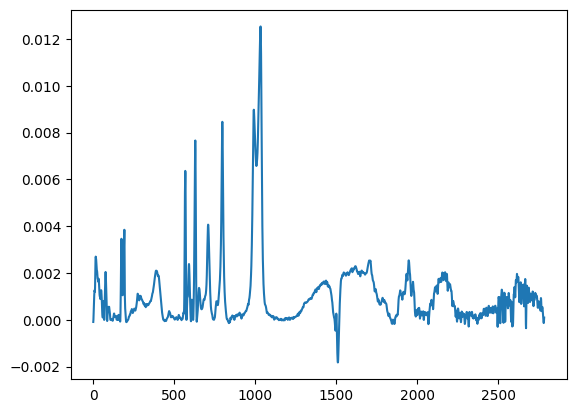

In [261]:
plt.plot(corrections[-2])

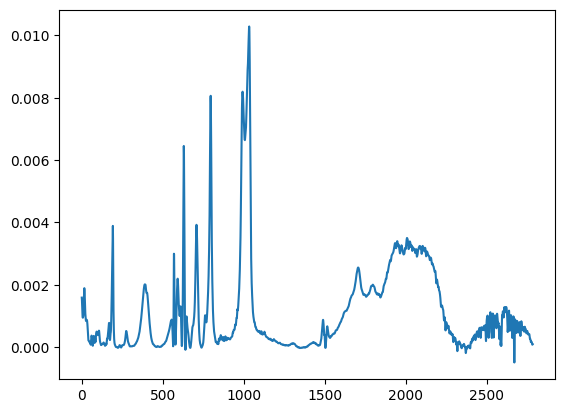

In [237]:
plt.plot(Y[2,:] - W @ nu - mu)

In [1]:
np.mean(corrs)

NameError: name 'np' is not defined

In [206]:
all_cors.append(corrs)

In [171]:
np.mean(corrs)

np.float64(0.9738786472618405)

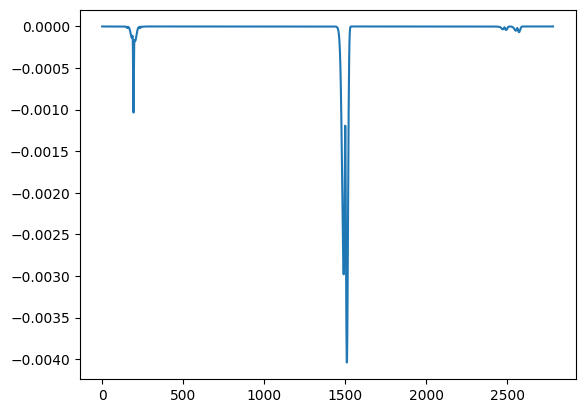

In [246]:
plt.plot(nu[-1]*W[:,-1])

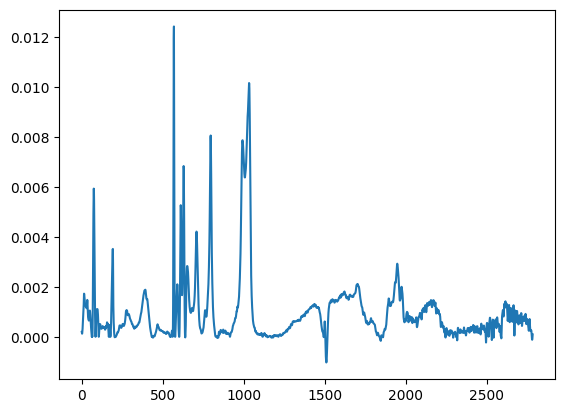

In [242]:
plt.plot(corrections[2,:])

In [172]:
np.mean(all_cors)

np.float64(0.9738786472618405)

In [ ]:
fun, jac_fun, init, bnds = veb_pb_optim_prep(
            y, tau, nu, d, mu, W
        )

opt = minimize(
            fun,
            init,
            method="L-BFGS-B",
            jac=jac_fun,
            bounds=bnds,
            options={"maxiter": 20000},
        )

tau, nu, t0 = opt.x[0], opt.x[1 : (1 + chat_ose)], chat_ose + 1
d = opt.x[t0:]
sigma_hat = pb_sigma_hat(y, tau, nu, d, mu, W)
gamma = d**2 + nu**2

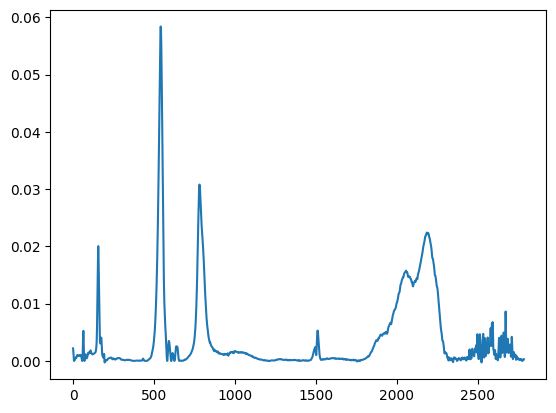

In [130]:
plt.plot(corrections[0])

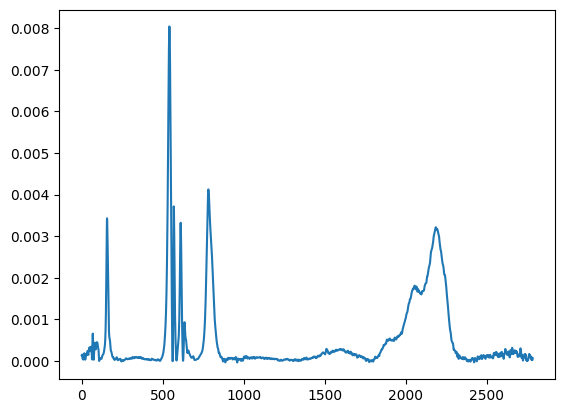

In [79]:
plt.plot(y - mu - W @ nu)

In [87]:


def pb_map(y, mu, W, tau, sigma, gamma, mit=None, verbose=False):
    x = cp.Variable(W.shape[1])
    prob = cp.Problem(
        cp.Minimize(
            cp.sum(0.5 * cp.abs(y - mu - W @ x) + (tau - 0.5) * (y - mu - W @ x))
            + 0.5 * sigma * cp.sum_squares(x/gamma)
        )
    )

    prob.solve(solver=cp.CLARABEL, verbose=verbose)

    return mu + W @ x.value, x.value